# Plot PyLLMPatch Instruction Distance Distributions

This notebook plots the distributions of the sum and normalized distance metrics from `pyllmpatch_semantic_error_distance.csv`.

Both plots are tightly zoomed so the main mass is visible and the long tail does not dominate. Outliers beyond the zoom range are shown sparsely as sampled markers at the right edge, together with an outlier count.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

In [2]:
load_dotenv()

project_root = Path(os.getenv("PROJECT_ROOT_DIR"))
csv_path = project_root / "dataset" / "results" / "pyllmpatch_semantic_error_distance.csv"

df = pd.read_csv(csv_path)
df = df[df["status"] == "summary"].copy()
df = df.sort_values("file_hash").reset_index(drop=True)
df[["file_hash", "sum_instruction_distance", "sum_control_flow_distance", "sum_interaction_penalty", "sum_unmatched_penalty", "sum_combined_distance", "sum_code_object_normalized_instruction_distance", "mean_code_object_normalized_instruction_distance", "mean_code_object_normalized_cfg_distance", "mean_code_object_normalized_combined_distance"]].head()

,file_hash,sum_instruction_distance,sum_control_flow_distance,sum_interaction_penalty,sum_unmatched_penalty,sum_combined_distance,sum_code_object_normalized_instruction_distance,mean_code_object_normalized_instruction_distance,mean_code_object_normalized_cfg_distance,mean_code_object_normalized_combined_distance
0,0003cc17c0694ad2a64411aa891571da06fa91039926de...,2.0,0.0,0.0,0.0,2.0,0.014706,0.003676,0.000000,0.003676
1,000637e3672e0ec68d9852c2f5a5b8bdb0abea256c904b...,5.0,0.0,0.0,0.0,5.0,0.108696,0.003623,0.000000,0.003623
2,000981a207911e3d469d4427beead4fc6d051a6c50d67d...,48.0,34.0,3.0,0.0,153.0,0.551724,0.078818,0.121429,0.453818
3,000cf7e0066e10719b961131a79dde7ef8ba8ab195861c...,26.0,4.0,3.0,0.0,41.0,0.495383,0.014570,0.006920,0.040522
4,0010438e4fa4dffbfbdb09adbd29d85c2cce65cd3c9be1...,50.0,23.0,3.0,0.0,122.0,1.000000,0.050000,0.047917,0.200000


In [3]:
def plot_zoomed_hist_with_normal(
    ax,
    values,
    title,
    xlabel,
    color,
    zoom_max=None,
    zoom_quantile=0.90,
    max_outlier_points=40,
):
    values = np.asarray(values, dtype=float)
    if zoom_max is None:
        zoom_max = float(np.quantile(values, zoom_quantile))

    in_range = values[values <= zoom_max]
    outliers = values[values > zoom_max]

    ax.hist(in_range, bins=30, density=True, color=color, alpha=0.65, edgecolor="black")
    ax.set_xlim(0, zoom_max)

    if len(in_range) > 1:
        mu = in_range.mean()
        sigma = in_range.std(ddof=0)
        if sigma > 0:
            xs = np.linspace(0, zoom_max, 300)
            ys = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2)
            ax.plot(xs, ys, color="black", linewidth=2, label=f"Normal fit in zoomed range: μ={mu:.3f}, σ={sigma:.3f}")

    if len(outliers) > 0:
        sample_count = min(len(outliers), max_outlier_points)
        ymax = ax.get_ylim()[1]
        y = np.full(sample_count, ymax * 0.05)
        x = np.full(sample_count, zoom_max)
        ax.scatter(x, y, color="red", s=18, alpha=0.6, marker="|", label=f"outliers > {zoom_max:.3f}: {len(outliers)}")
        ax.text(
            zoom_max * 0.98,
            ymax * 0.92,
            f"{len(outliers)} outliers > {zoom_max:.3f}",
            ha="right",
            va="top",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
        )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("density")
    ax.legend()

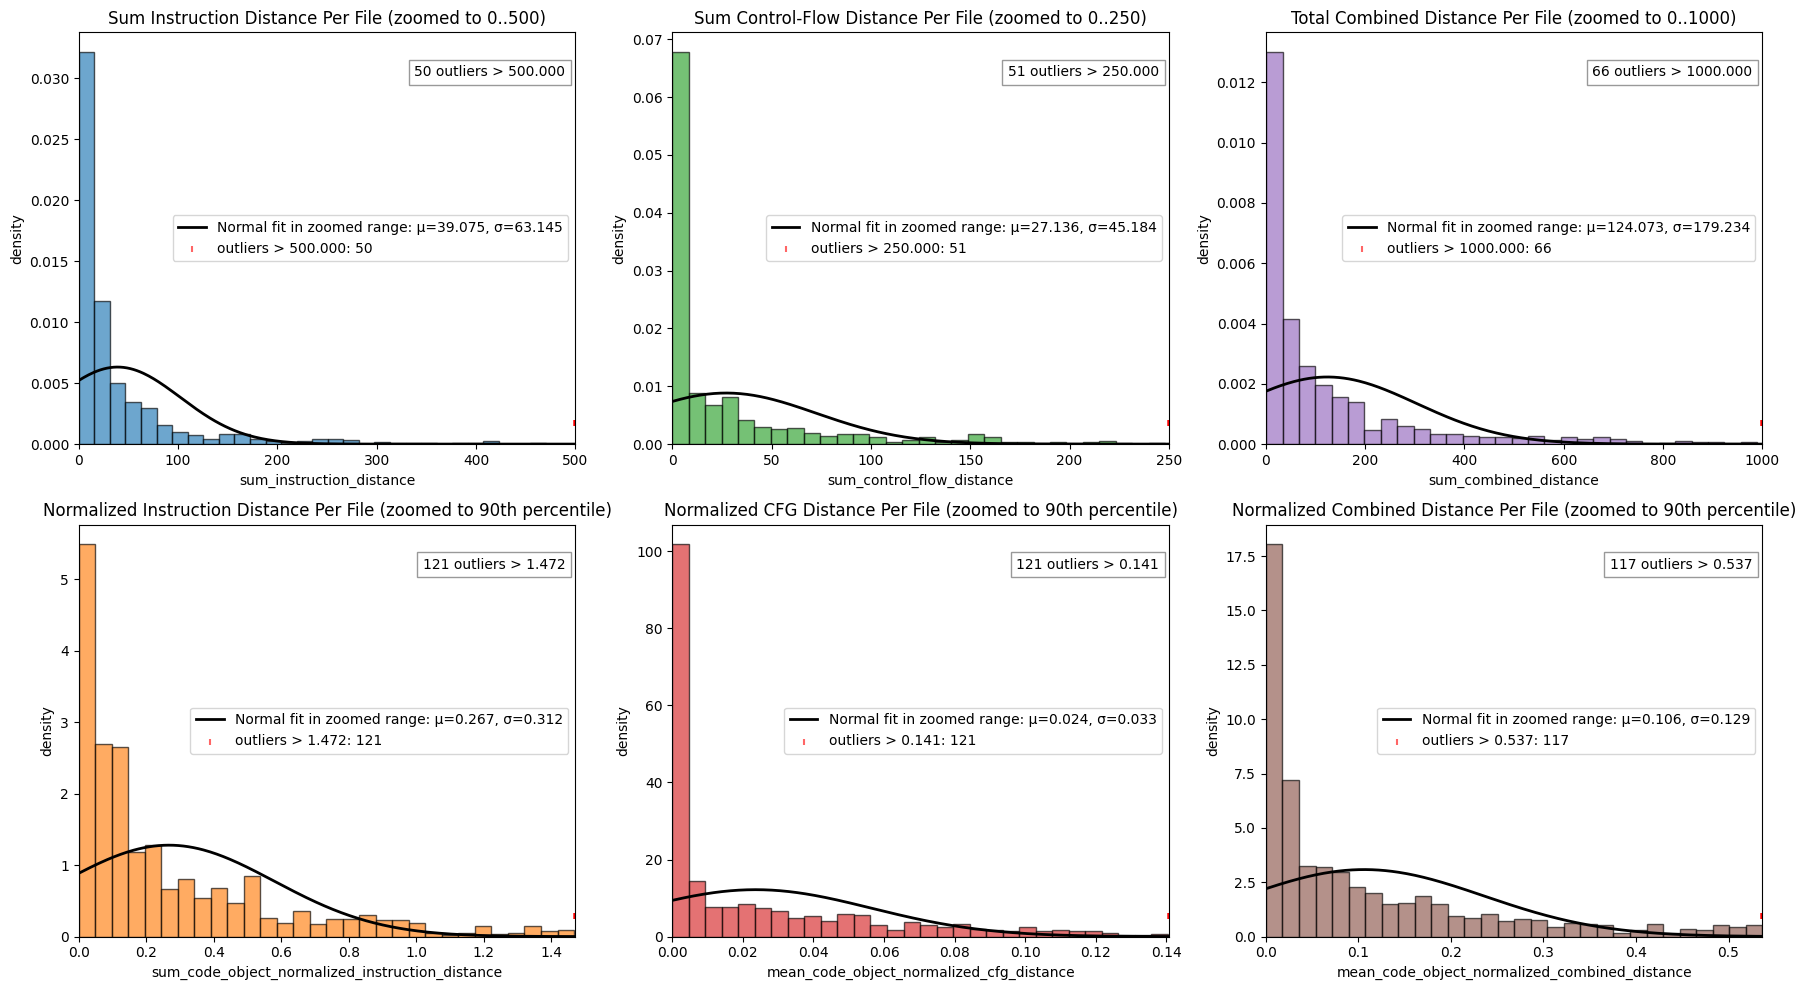

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_zoomed_hist_with_normal(
    axes[0, 0],
    df["sum_instruction_distance"],
    "Sum Instruction Distance Per File (zoomed to 0..500)",
    "sum_instruction_distance",
    "tab:blue",
    zoom_max=500,
)

plot_zoomed_hist_with_normal(
    axes[0, 1],
    df["sum_control_flow_distance"],
    "Sum Control-Flow Distance Per File (zoomed to 0..250)",
    "sum_control_flow_distance",
    "tab:green",
    zoom_max=250,
)

plot_zoomed_hist_with_normal(
    axes[0, 2],
    df["sum_combined_distance"],
    "Total Combined Distance Per File (zoomed to 0..1000)",
    "sum_combined_distance",
    "tab:purple",
    zoom_max=1000,
)

plot_zoomed_hist_with_normal(
    axes[1, 0],
    df["sum_code_object_normalized_instruction_distance"],
    "Normalized Instruction Distance Per File (zoomed to 90th percentile)",
    "sum_code_object_normalized_instruction_distance",
    "tab:orange",
    zoom_max=None,
    zoom_quantile=0.90,
)
plot_zoomed_hist_with_normal(
    axes[1, 1],
    df["mean_code_object_normalized_cfg_distance"],
    "Normalized CFG Distance Per File (zoomed to 90th percentile)",
    "mean_code_object_normalized_cfg_distance",
    "tab:red",
    zoom_max=None,
    zoom_quantile=0.90,
)
plot_zoomed_hist_with_normal(
    axes[1, 2],
    df["mean_code_object_normalized_combined_distance"],
    "Normalized Combined Distance Per File (zoomed to 90th percentile)",
    "mean_code_object_normalized_combined_distance",
    "tab:brown",
    zoom_max=None,
    zoom_quantile=0.90,
)

plt.tight_layout()
plt.show()